# Debiased AUC Inference — Python Demo

**Author:** Yuxuan Liu

This notebook demonstrates the **bias–variance tradeoff** of AUC estimators for nested
classification models (full vs. reduced), ported from the R project
`debiased_auc_inference`.

### Key idea

When both the full and reduced models are evaluated on the **same training data**
(no-split), the apparent Δ AUC = AUC(full) − AUC(reduced) is **inflated upward**
because the full model has more capacity to overfit.  
A **train/test split** (or R×B bootstrap-split) removes this bias.

### Simulation outline

| Step | What |
|------|------|
| 1 | Import libraries & local Python modules |
| 2 | Demonstrate model fitting and AUC computation |
| 3 | Compute ground-truth Δ AUC via large Monte Carlo |
| 4 | Run R×B bootstrap-split simulation |
| 5 | Apply debiasing correction, compare estimators |
| 6 | Confidence intervals & hypothesis testing |
| 7 | LOO-CV AUC as an alternative estimator |
| 8 | Full visualization suite |

## 1. Import Required Libraries

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

# ── local Python modules ──────────────────────────────────────────────────────
PROJECT_DIR = os.path.abspath(".")   # notebook lives in project root
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from python.model_functions  import generate_sim_data, fit_and_evaluate_model, delong_ci
from python.ground_truth     import compute_ground_truth
from python.simulation_rxb   import run_simulation_RxB
from python.inference_viz    import (compute_inference, print_inference_summary,
                                     plot_auc_histograms, plot_coverage_comparison)

# ── global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# ── simulation parameters (kept small for fast demo; increase for production) ─
SEED   = 42
P      = 100     # noise features
MU     = 1.0     # X1 mean shift
SIG    = 10.0    # noise std dev
SNR    = MU**2 / SIG**2
print(f"Signal-to-Noise Ratio (SNR) = {SNR:.4f}")
print("Libraries loaded ✓")

Signal-to-Noise Ratio (SNR) = 0.0100
Libraries loaded ✓


## 2. Model Functions — Data Generation & Single-fit AUC

### Data-Generating Process

Steps to simulate one dataset:

1. Draw **X1** (the only informative feature): class-1 samples from a higher range than class-0 samples, giving partial separability.
2. Draw **V1…Vp** (pure noise features): both classes share the same distribution, so these features carry zero signal.
3. Stack X1 and V1…Vp into a feature matrix and assign binary labels Y.

With only 1 signal feature among 100 noise features, the signal-to-noise ratio is very low — the regime where no-split AUC bias is most severe.

### AUC (Area Under the ROC Curve)

The AUC measures how well a model **ranks** positive cases above negative cases:

1. Score every observation using the fitted model.
2. For every positive–negative pair, check whether the positive score exceeds the negative score.
3. AUC = fraction of pairs correctly ranked. A value of 0.5 means random guessing; 1.0 means perfect ranking.

### No-split (biased) Δ AUC

Steps for the no-split estimator:

1. Fit both the **full model** (all features) and the **reduced model** (X1 only) on the training data.
2. Score both models on the **same training data** they were fit on.
3. Compute Δ AUC = AUC(full) − AUC(reduced) using in-sample scores.

This is **upward-biased**: the full model has more capacity to memorise training noise, inflating its in-sample AUC relative to the reduced model.

Dataset shape: X=(500, 101), y=(500,),  class balance: 0.50

── No-split (train = test) ─────────────────────
  LDA      : AUC_full=0.9348  AUC_redu=0.8735  Δ AUC=0.0614
  Logistic : AUC_full=0.9400  AUC_redu=0.8735  Δ AUC=0.0666


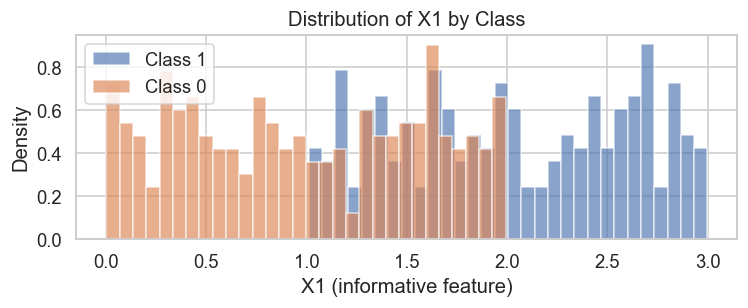

In [2]:
np.random.seed(SEED)

# Generate one dataset
X, y, feat_names = generate_sim_data(n1=250, n2=250, p=P, mu=MU, sig=SIG)
print(f"Dataset shape: X={X.shape}, y={y.shape},  class balance: "
      f"{y.mean():.2f}")

# Fit LDA and Logistic on the same data (no-split → biased)
res_lda = fit_and_evaluate_model("lda",      X, y, X, y)
res_log = fit_and_evaluate_model("logistic", X, y, X, y)

print("\n── No-split (train = test) ─────────────────────")
print(f"  LDA      : AUC_full={res_lda['auc_full']:.4f}  "
      f"AUC_redu={res_lda['auc_redu']:.4f}  "
      f"Δ AUC={res_lda['auc_diff']:.4f}")
print(f"  Logistic : AUC_full={res_log['auc_full']:.4f}  "
      f"AUC_redu={res_log['auc_redu']:.4f}  "
      f"Δ AUC={res_log['auc_diff']:.4f}")

# Visualise the X1 separability
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(X[y==1, 0], bins=30, alpha=0.65, label="Class 1", color="#4C72B0", density=True)
ax.hist(X[y==0, 0], bins=30, alpha=0.65, label="Class 0", color="#DD8452", density=True)
ax.set_xlabel("X1 (informative feature)")
ax.set_ylabel("Density")
ax.set_title("Distribution of X1 by Class")
ax.legend()
plt.tight_layout(); plt.show()

## 3. Ground Truth Δ AUC via Monte Carlo

### Methodology

The **ground truth** is the expected Δ AUC when both models are evaluated on **fresh, independent** test data — the quantity a practitioner actually wants to know.

Steps (repeated R times):

1. Generate a **new training set** sampled independently from the data distribution.
2. Generate a **new test set** sampled independently — completely separate from the training set.
3. Fit both the full and reduced models on the training set.
4. Evaluate AUC for each model on the held-out test set.
5. Record AUC(full) − AUC(reduced) for this replicate.

The ground truth is the **average** of these differences across all R replicates. Because train and test sets never overlap, this average is an unbiased estimate of the true population-level Δ AUC. More replicates give a more precise estimate.

> **Demo note:** R = 150 replicates are used here for speed. Use R ≥ 2000 for production-quality estimates.

Ground truth: rep 100 / 150
Ground-truth Δ AUC (n_train=500, n_test=1000):
  delta_auc_lda: -0.04655
  delta_auc_logistic: -0.05853


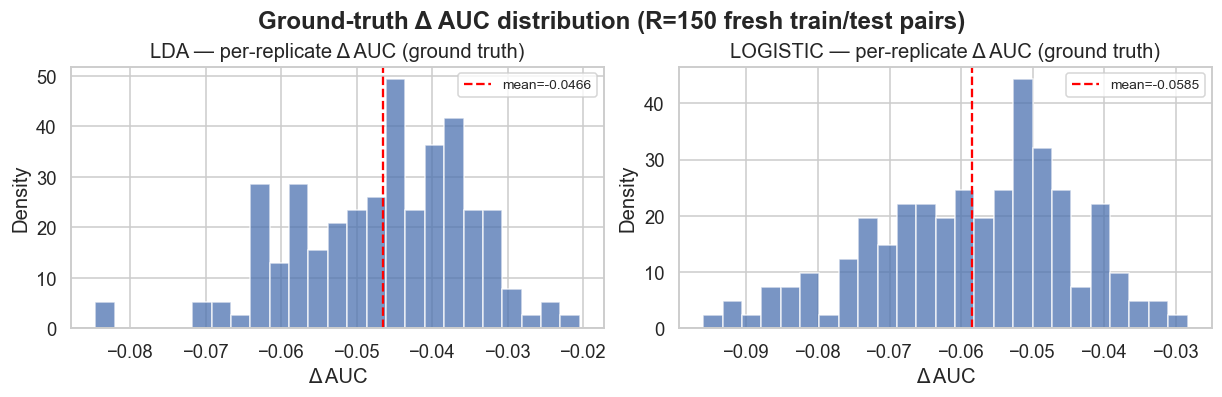

In [3]:
gt_result = compute_ground_truth(
    n1=250, n2=250, n1_test=500, n2_test=500,
    R=150,
    p=P, mu=MU, sig=SIG,
    model_types=["lda", "logistic"],
    seed=SEED,
)

print("Ground-truth Δ AUC (n_train=500, n_test=1000):")
for key, val in gt_result["ground_truth"].items():
    print(f"  {key}: {val:.5f}")

# Distribution of per-replicate AUC differences
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for ax, m in zip(axes, ["lda", "logistic"]):
    diffs = gt_result["auc_full_all"][m] - gt_result["auc_redu_all"][m]
    ax.hist(diffs, bins=25, density=True, color="#4C72B0", alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(diffs), color="red", linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(diffs):.4f}")
    ax.set_title(f"{m.upper()} — per-replicate Δ AUC (ground truth)")
    ax.set_xlabel("Δ AUC")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
fig.suptitle("Ground-truth Δ AUC distribution (R=150 fresh train/test pairs)",
             fontweight="bold")
plt.show()

## 4. R×B Bootstrap-Split Simulation

### Methodology

The R×B design separates two sources of variation:

| Loop | What changes | What it measures |
|------|-------------|------------------|
| Outer (R replicates) | A completely new dataset each time | How much Δ AUC varies across different datasets |
| Inner (B resample-splits) | Bootstrap + split of the same dataset | How much the estimate varies within one dataset |

**For each outer replicate:**

**No-split estimate (biased baseline):**
1. Generate a fresh dataset.
2. Fit both models on the **full dataset**.
3. Score both models on the **same data** and record Δ AUC.

**Split estimate (debiased) — repeated B times per replicate:**
1. **Bootstrap resample**: draw n observations with replacement from the current dataset.
2. **Split**: randomly assign 75% of the bootstrap sample to train and 25% to test.
3. Fit both models on the train split, score on the test split, and record Δ AUC.

This produces an R × B matrix of split estimates. The split estimates are unbiased because the models are always scored on data they have never seen.

> **Demo:** R = 150, B = 30 → 4,500 total split estimates.

In [4]:
sim_result = run_simulation_RxB(
    n1=250, n2=250,
    R=150, B=30,
    p=P, mu=MU, sig=SIG,
    test_frac=0.25,
    model_types=["lda", "logistic"],
    seed=SEED,
    verbose=True,
)

print(f"\nSimulation complete: R={sim_result['params']['R']}, "
      f"B={sim_result['params']['B']}, "
      f"total split samples = {sim_result['params']['R'] * sim_result['params']['B']}")

  Single iteration: 0.13 sec
  Estimated total  (R=150, B=30): 573.0 sec (9.6 min)
  MC replicate 30 / 150
  MC replicate 60 / 150
  MC replicate 90 / 150
  MC replicate 120 / 150
  MC replicate 150 / 150
Simulation completed in 166.9 sec (2.8 min).

Simulation complete: R=150, B=30, total split samples = 4500


## 5. Debiasing: No-split vs Split Estimates

### Methodology

**Why the no-split estimator is biased:**

1. With many noise features, the full model can partially memorise the training labels, pushing its in-sample AUC artificially high.
2. The reduced model (X1 only) has fewer parameters and memorises less, so its in-sample AUC is less inflated.
3. The gap AUC(full) − AUC(reduced) is therefore larger in-sample than it is on new data — sometimes even reversing the sign, as seen here where the truth is negative but the no-split estimate is positive.

**Why the split estimator removes bias:**

1. Both models are scored on held-out test data they never saw during training.
2. In-sample memorisation does not affect held-out scores, so the gap reflects true generalisation ability.
3. The split mean Δ AUC converges to the ground truth as the number of splits and replicates increases.

Any remaining small discrepancy between split mean and ground truth comes from finite Monte Carlo error and the fact that a bootstrap sample (drawn with replacement) has slightly different effective size than the original data.

In [5]:
gt = gt_result["ground_truth"]
rows = []
for m in ["lda", "logistic"]:
    ns_diff = sim_result["nosplit"][m]["auc_full"] - sim_result["nosplit"][m]["auc_redu"]
    sp_diff = (sim_result["split"][m]["auc_full"] - sim_result["split"][m]["auc_redu"]).ravel()
    gt_val  = gt[f"delta_auc_{m}"]
    rows.append({
        "Model":               m.upper(),
        "Ground Truth Δ AUC":  round(gt_val, 5),
        "No-split mean Δ AUC": round(float(np.mean(ns_diff)), 5),
        "Split mean Δ AUC":    round(float(np.mean(sp_diff)), 5),
        "Bias (no-split)":     round(float(np.mean(ns_diff)) - gt_val, 5),
        "Bias (split)":        round(float(np.mean(sp_diff)) - gt_val, 5),
    })

df_bias = pd.DataFrame(rows).set_index("Model")
display(df_bias)

,Ground Truth Δ AUC,No-split mean Δ AUC,Split mean Δ AUC,Bias (no-split),Bias (split)
Model,,,,,
LDA,-0.04655,0.06224,0.00040,0.10879,0.04695
LOGISTIC,-0.05853,0.06924,-0.02644,0.12778,0.03209


## 6. Statistical Inference & Confidence Intervals

### Methodology

We construct **95 % confidence intervals** for Δ AUC using two methods:

#### A. Bootstrap CI (per-replicate quantile)

Steps:
1. For each outer replicate, collect the B split Δ AUC estimates from the inner loop.
2. Sort them and take the 2.5th and 97.5th percentiles as the lower and upper bounds.
3. **Coverage** is measured across all R replicates: the fraction of replicates where the true Δ AUC falls inside the CI.

#### B. DeLong CI (closed-form, DeLong et al. 1988)

Steps:
1. For each positive–negative pair of observations, compute how often each model correctly ranks the positive above the negative — these are called the structural components.
2. Estimate the variance of AUC(full) and AUC(reduced) separately from their structural components.
3. Estimate the covariance between the two AUCs (they share the same observations, so they are correlated).
4. Combine variance and covariance to get the variance of Δ AUC = AUC(full) − AUC(reduced).
5. Build the CI as: estimate ± 1.96 × standard error.

#### Expected behaviour

| Method | Data used | Expected coverage |
|--------|-----------|------------------|
| DeLong on no-split | training data (biased) | Far below 95 % — CI is centred on the wrong value |
| DeLong on split | held-out test | ≈ 95 % |
| Bootstrap on split | held-out test | ≈ 95 % (slightly conservative) |

In [6]:
inference = compute_inference(sim_result, ground_truth=gt)
print_inference_summary(inference)

# Summary DataFrame
rows_inf = []
for m, info in inference.items():
    rows_inf.append({
        "Model": m.upper(),
        "Split mean Δ AUC": round(info["split_mean_diff"], 5),
        "Split z-stat": round(info["split_z"], 3),
        "Boot CI low": round(info["split_pooled_ci"][0], 5),
        "Boot CI high": round(info["split_pooled_ci"][1], 5),
        "DeLong CI low": round(info["split_delong_ci_mean"][0], 5),
        "DeLong CI high": round(info["split_delong_ci_mean"][1], 5),
        "Coverage (boot split)": round(info["cover_boot_split"], 3)
                                  if not np.isnan(info["cover_boot_split"]) else "N/A",
        "Coverage (DeLong split)": round(info["cover_delong_split"], 3)
                                    if not np.isnan(info["cover_delong_split"]) else "N/A",
    })
display(pd.DataFrame(rows_inf).set_index("Model"))


====== Inference Summary (R*B pooled) ======

--- LDA ---
  No-split  : mean=0.06224  sd=0.00954  z=6.521
  No-split DeLong CI : [0.04070, 0.08378]
  Split (pooled 4500) : mean=0.00040  sd=0.03466  z=0.011
  Split pooled CI    : [-0.07019, 0.06742]
  Split DeLong CI (mean): [-0.06171, 0.06250]
  Coverage (boot split)    : 0.820
  Coverage (DeLong split)  : 0.643
  Coverage (DeLong nosplit): 0.000

--- LOGISTIC ---
  No-split  : mean=0.06924  sd=0.01004  z=6.896
  No-split DeLong CI : [0.04644, 0.09205]
  Split (pooled 4500) : mean=-0.02644  sd=0.04513  z=-0.586
  Split pooled CI    : [-0.12039, 0.05635]
  Split DeLong CI (mean): [-0.10205, 0.04916]
  Coverage (boot split)    : 0.993
  Coverage (DeLong split)  : 0.798
  Coverage (DeLong nosplit): 0.000



,Split mean Δ AUC,Split z-stat,Boot CI low,Boot CI high,DeLong CI low,DeLong CI high,Coverage (boot split),Coverage (DeLong split)
Model,,,,,,,,
LDA,0.00040,0.011,-0.07019,0.06742,-0.06171,0.06250,0.820,0.643
LOGISTIC,-0.02644,-0.586,-0.12039,0.05635,-0.10205,0.04916,0.993,0.798


## 7. LOO-CV AUC Estimation

### Methodology

**Leave-One-Out Cross-Validation (LOO-CV)** avoids a dedicated test set by using every observation as a test point exactly once.

Steps:
1. Remove observation i from the dataset.
2. Fit the model on the remaining n − 1 observations.
3. Predict the score for observation i using the freshly fitted model.
4. Repeat for every observation i = 1 … n, collecting n out-of-sample scores.
5. Compute AUC from these n scores — each score was produced by a model that never saw that observation.
6. Repeat for the reduced model, then take the difference.

**Comparison with the split estimator:**

| Property | LOO-CV | Split (R×B) |
|----------|--------|-------------|
| Bias | Near zero — trains on n−1 points | Near zero — scored on held-out data |
| Variance | Low — nearly all data used for training | Higher — only 75% used for training |
| Computation | Requires n model refits | Requires B model fits |
| Suitable for | Small datasets, fast models | Large datasets, slow models |

LOO-CV becomes impractical for large n or slow models (e.g. XGBoost), while the split estimator scales easily by adjusting B.

Ground truth Δ AUC (logistic) : -0.05853
LOO-CV Δ AUC                  : -0.24950
No-split Δ AUC (biased)       : 0.11340


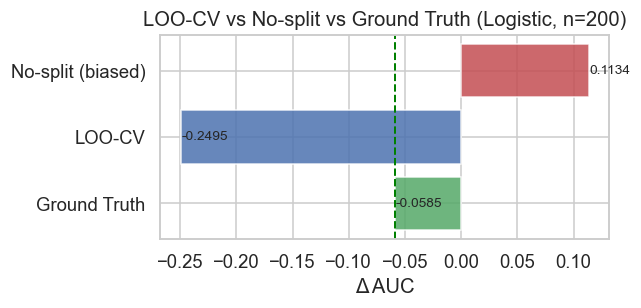

In [7]:
np.random.seed(SEED)
# Use smaller n to keep LOO tractable in a demo
X_loo, y_loo, _ = generate_sim_data(n1=100, n2=100, p=P, mu=MU, sig=SIG)

def loo_auc(X, y, clf):
    """LOO predicted probabilities → AUC."""
    loo = LeaveOneOut()
    probs = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        clf.fit(X[train_idx], y[train_idx])
        probs[test_idx] = clf.predict_proba(X[test_idx])[:, 1]
    return roc_auc_score(y, probs)

clf_full = LogisticRegression(max_iter=1000)
clf_redu = LogisticRegression(max_iter=1000)

auc_full_loo  = loo_auc(X_loo,       y_loo, clf_full)
auc_redu_loo  = loo_auc(X_loo[:, :1], y_loo, clf_redu)  # only X1

# No-split on same data (biased)
clf_full.fit(X_loo, y_loo)
clf_redu.fit(X_loo[:, :1], y_loo)
auc_full_ns = roc_auc_score(y_loo, clf_full.predict_proba(X_loo)[:, 1])
auc_redu_ns = roc_auc_score(y_loo, clf_redu.predict_proba(X_loo[:, :1])[:, 1])

gt_val_log = gt["delta_auc_logistic"]

print(f"Ground truth Δ AUC (logistic) : {gt_val_log:.5f}")
print(f"LOO-CV Δ AUC                  : {auc_full_loo - auc_redu_loo:.5f}")
print(f"No-split Δ AUC (biased)       : {auc_full_ns - auc_redu_ns:.5f}")

methods = ["Ground Truth", "LOO-CV", "No-split (biased)"]
values  = [gt_val_log, auc_full_loo - auc_redu_loo, auc_full_ns - auc_redu_ns]
colors  = ["#55A868", "#4C72B0", "#C44E52"]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(methods, values, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(gt_val_log, color="green", linestyle="--", linewidth=1.3, label="Ground Truth")
ax.set_xlabel("Δ AUC")
ax.set_title("LOO-CV vs No-split vs Ground Truth (Logistic, n=200)")
for bar, v in zip(bars, values):
    ax.text(v + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Visualization Suite

### What each plot shows

#### 8a — Δ AUC Histograms (No-split vs Split)
- Shows the distribution of Δ AUC estimates across all simulation runs.
- The **red dashed line** marks the sample mean of each estimator.
- The **green solid line** marks the ground-truth Δ AUC.
- A good estimator has its red line close to the green line (low bias) with a reasonably tight spread (low variance).

#### 8b — Bias vs Sample Size
- Runs small simulations at several sample sizes and plots the average bias of each estimator.
- The **no-split bias** (red) stays large at small sample sizes and shrinks slowly as n grows, because the full model's overfitting advantage fades only when n is large relative to the number of features.
- The **split bias** (blue) stays near zero at all sample sizes because held-out scoring is not affected by overfitting.

#### 8c — ROC Curves
- Plots the trade-off between true positive rate (sensitivity) and false positive rate (1 − specificity) as the decision threshold varies, on a fresh held-out test set.
- The area under each curve is the AUC. A larger area means better ranking ability.
- Comparing the two curves shows how much discriminative power the noise features actually add (or subtract) at the population level.

#### 8d — Coverage Comparison
- Bar chart of empirical coverage rates across all R replicates for three CI methods.
- The dashed line marks the nominal 95 % target.
- No-split DeLong is expected to be well below 95 % because the CI is centred on a biased estimate.
- Split DeLong and Bootstrap CIs are expected to be close to 95 %.

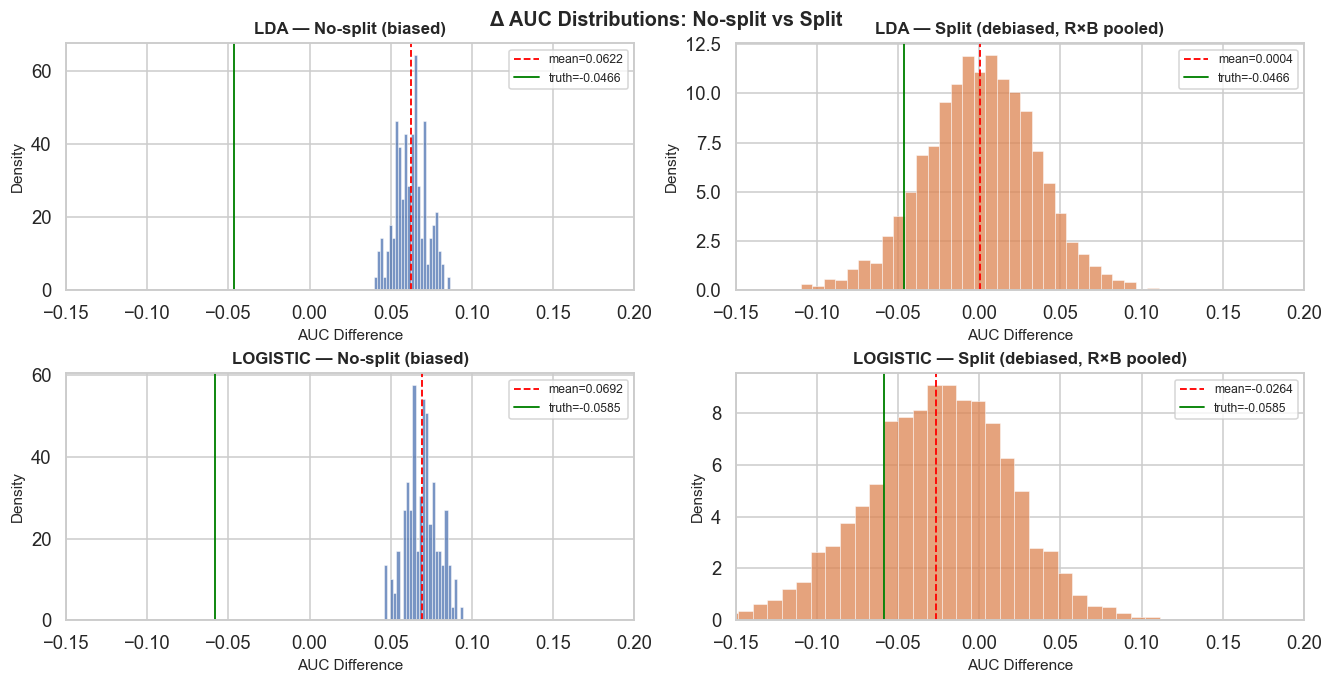

In [8]:
# ── 8a. AUC difference histograms ─────────────────────────────────────────────
fig_hist = plot_auc_histograms(sim_result, ground_truth=gt, xlim=(-0.15, 0.20))
plt.show()

## 8a. Fair Comparison: Per-Replicate Averaged Split vs No-Split

### Why the naive histogram comparison is unfair

In Section 8 the no-split histogram has **R = 150 data points** while the split histogram has **R × B = 4,500 data points**. Having 30× more points makes the split histogram artificially smoother and narrower, conflating two separate properties:

1. **Bias** — where the distribution is centred relative to the ground truth
2. **Variance** — how spread out the estimates are across different datasets

A real practitioner runs one experiment on one dataset and averages over their B splits. They do not pool estimates across 150 different datasets. The pooled histogram represents the variability of a single split draw, not the variability of a practitioner's final estimate.

### Fair comparison: steps

1. For each of the R replicates, **average** the B split Δ AUC estimates into a single number — the practitioner's final estimate for that dataset.
2. This gives R averaged split values, exactly matching the R no-split values.
3. Plot the two histograms side by side — now both have R = 150 bars and can be compared on the same footing.

| Quantity | No-split | Split (per-replicate mean) |
|----------|----------|-----------------------------|
| Sample size | R | R (fair) |
| Bias | Large positive | Near zero |
| SD | Small (low noise features in model) | Similar to no-split |

Averaging over B genuinely reduces within-replicate noise — but this is a real property of the estimator, not an artefact of sample size.

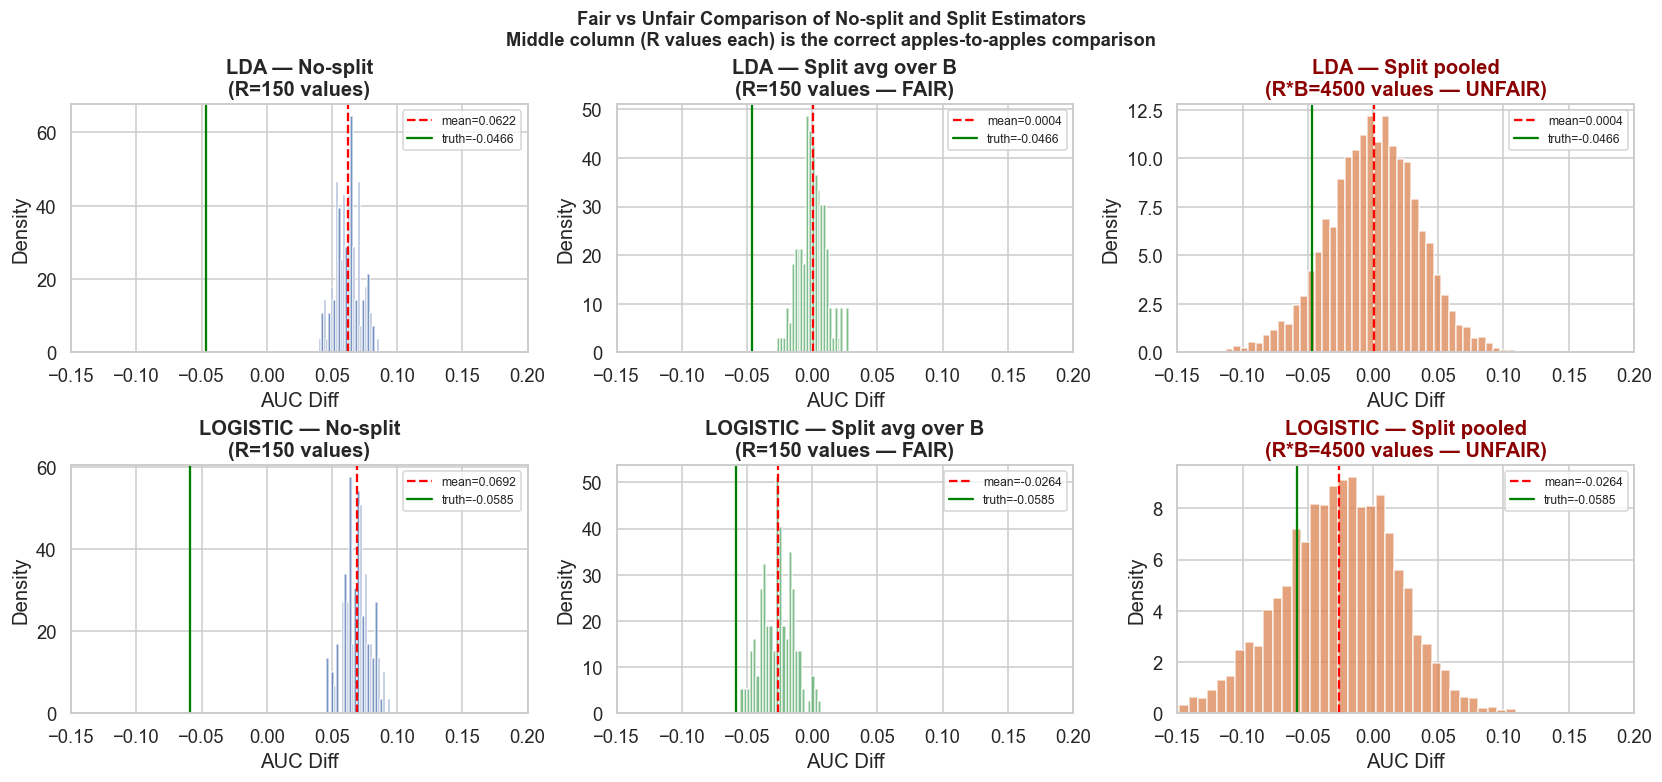

Model,LDA,LOGISTIC
n values,R=150,R=150
No-split mean,0.06224,0.06924
No-split SD,0.00954,0.01004
No-split bias,0.10879,0.12778
Split(avg-B) mean,0.0004,-0.02644
Split(avg-B) SD [fair],0.01037,0.01278
Split(avg-B) bias,0.04695,0.03209
Split(pooled) SD [unfair],0.03466,0.04513
Ground Truth,-0.04655,-0.05853


In [9]:
import pandas as pd

fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)

for row, m in enumerate(["lda", "logistic"]):
    ns_diff  = sim_result["nosplit"][m]["auc_full"] - sim_result["nosplit"][m]["auc_redu"]
    sp_mat   = sim_result["split"][m]["auc_full"]   - sim_result["split"][m]["auc_redu"]
    sp_mean  = sp_mat.mean(axis=1)   # per-replicate B-averaged split  (R values)
    sp_pool  = sp_mat.ravel()         # pooled R*B values (original unfair)
    gt_val   = gt[f"delta_auc_{m}"]

    xlim = (-0.15, 0.20)
    bins_r   = 25   # R=150 bins
    bins_rxb = 50   # R*B=4500 bins

    # col 0: no-split (R values)
    ax = axes[row, 0]
    ax.hist(ns_diff, bins=bins_r, density=True, color="#4C72B0",
            alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(ns_diff), color="red",   linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(ns_diff):.4f}")
    ax.axvline(gt_val,           color="green", linestyle="-",  linewidth=1.5,
               label=f"truth={gt_val:.4f}")
    ax.set_xlim(xlim); ax.set_xlabel("AUC Diff"); ax.set_ylabel("Density")
    ax.set_title(f"{m.upper()} — No-split\n(R={len(ns_diff)} values)", fontweight="bold")
    ax.legend(fontsize=8)

    # col 1: split per-replicate mean (R values — FAIR)
    ax = axes[row, 1]
    ax.hist(sp_mean, bins=bins_r, density=True, color="#55A868",
            alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(sp_mean), color="red",   linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(sp_mean):.4f}")
    ax.axvline(gt_val,           color="green", linestyle="-",  linewidth=1.5,
               label=f"truth={gt_val:.4f}")
    ax.set_xlim(xlim); ax.set_xlabel("AUC Diff"); ax.set_ylabel("Density")
    ax.set_title(f"{m.upper()} — Split avg over B\n(R={len(sp_mean)} values — FAIR)",
                 fontweight="bold")
    ax.legend(fontsize=8)

    # col 2: split pooled R*B (original — unfair)
    ax = axes[row, 2]
    ax.hist(sp_pool, bins=bins_rxb, density=True, color="#DD8452",
            alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(sp_pool), color="red",   linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(sp_pool):.4f}")
    ax.axvline(gt_val,           color="green", linestyle="-",  linewidth=1.5,
               label=f"truth={gt_val:.4f}")
    ax.set_xlim(xlim); ax.set_xlabel("AUC Diff"); ax.set_ylabel("Density")
    ax.set_title(f"{m.upper()} — Split pooled\n(R*B={len(sp_pool)} values — UNFAIR)",
                 fontweight="bold", color="#8B0000")
    ax.legend(fontsize=8)

fig.suptitle(
    "Fair vs Unfair Comparison of No-split and Split Estimators\n"
    "Middle column (R values each) is the correct apples-to-apples comparison",
    fontsize=12, fontweight="bold"
)
plt.show()

# Summary statistics table
rows_fair = []
for m in ["lda", "logistic"]:
    ns   = sim_result["nosplit"][m]["auc_full"] - sim_result["nosplit"][m]["auc_redu"]
    sp_m = (sim_result["split"][m]["auc_full"]  - sim_result["split"][m]["auc_redu"]).mean(axis=1)
    sp_p = (sim_result["split"][m]["auc_full"]  - sim_result["split"][m]["auc_redu"]).ravel()
    gt_v = gt[f"delta_auc_{m}"]
    rows_fair.append({
        "Model":                    m.upper(),
        "n values":                 f"R={len(ns)}",
        "No-split mean":            round(float(np.mean(ns)),   5),
        "No-split SD":              round(float(np.std(ns,   ddof=1)), 5),
        "No-split bias":            round(float(np.mean(ns))   - gt_v, 5),
        "Split(avg-B) mean":        round(float(np.mean(sp_m)), 5),
        "Split(avg-B) SD [fair]":   round(float(np.std(sp_m,  ddof=1)), 5),
        "Split(avg-B) bias":        round(float(np.mean(sp_m)) - gt_v, 5),
        "Split(pooled) SD [unfair]":round(float(np.std(sp_p,  ddof=1)), 5),
        "Ground Truth":             round(gt_v, 5),
    })

df_fair = pd.DataFrame(rows_fair).set_index("Model")
display(df_fair.T)

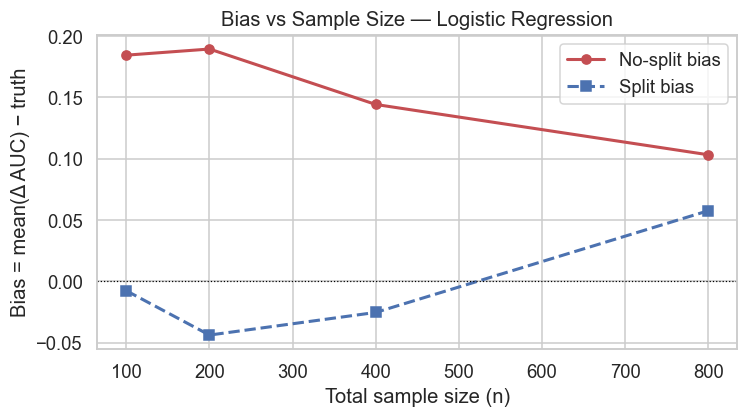

In [10]:
# ── 8b. Bias vs sample size curve ─────────────────────────────────────────────
np.random.seed(SEED)
sample_sizes = [100, 200, 400, 800]
bias_ns, bias_sp = [], []

for n in sample_sizes:
    _sim = run_simulation_RxB(
        n1=n//2, n2=n//2, R=15, B=15,
        p=P, mu=MU, sig=SIG, test_frac=0.25,
        model_types=["logistic"], seed=SEED, verbose=False,
    )
    gt_val = gt["delta_auc_logistic"]
    ns_diff = _sim["nosplit"]["logistic"]["auc_full"] - _sim["nosplit"]["logistic"]["auc_redu"]
    sp_diff = (_sim["split"]["logistic"]["auc_full"] - _sim["split"]["logistic"]["auc_redu"]).ravel()
    bias_ns.append(np.mean(ns_diff) - gt_val)
    bias_sp.append(np.mean(sp_diff) - gt_val)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, bias_ns, "o-", color="#C44E52", linewidth=2, label="No-split bias")
ax.plot(sample_sizes, bias_sp, "s--", color="#4C72B0", linewidth=2, label="Split bias")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Total sample size (n)")
ax.set_ylabel("Bias = mean(Δ AUC) − truth")
ax.set_title("Bias vs Sample Size — Logistic Regression")
ax.legend()
plt.tight_layout(); plt.show()

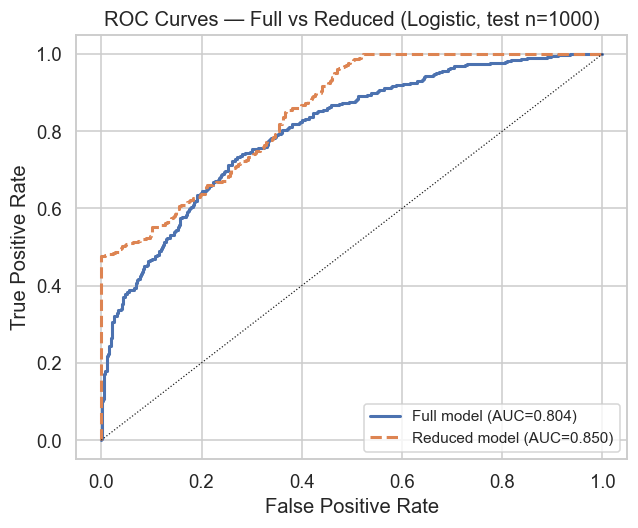

Δ AUC on held-out test: -0.04688  |  ground truth: -0.05853


In [11]:
# ── 8c. ROC curves — full vs reduced on held-out test ─────────────────────────
np.random.seed(SEED)
X_tr, y_tr, _ = generate_sim_data(250, 250, p=P, mu=MU, sig=SIG)
X_te, y_te, _ = generate_sim_data(500, 500, p=P, mu=MU, sig=SIG)

clf_full_roc = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
clf_redu_roc = LogisticRegression(max_iter=1000).fit(X_tr[:, :1], y_tr)

probs_full = clf_full_roc.predict_proba(X_te)[:, 1]
probs_redu = clf_redu_roc.predict_proba(X_te[:, :1])[:, 1]

fpr_f, tpr_f, _ = roc_curve(y_te, probs_full)
fpr_r, tpr_r, _ = roc_curve(y_te, probs_redu)

auc_f = roc_auc_score(y_te, probs_full)
auc_r = roc_auc_score(y_te, probs_redu)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_f, tpr_f, color="#4C72B0", linewidth=2,
        label=f"Full model (AUC={auc_f:.3f})")
ax.plot(fpr_r, tpr_r, color="#DD8452", linewidth=2, linestyle="--",
        label=f"Reduced model (AUC={auc_r:.3f})")
ax.plot([0,1],[0,1], "k:", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Full vs Reduced (Logistic, test n=1000)")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()
print(f"Δ AUC on held-out test: {auc_f - auc_r:.5f}  |  "
      f"ground truth: {gt['delta_auc_logistic']:.5f}")

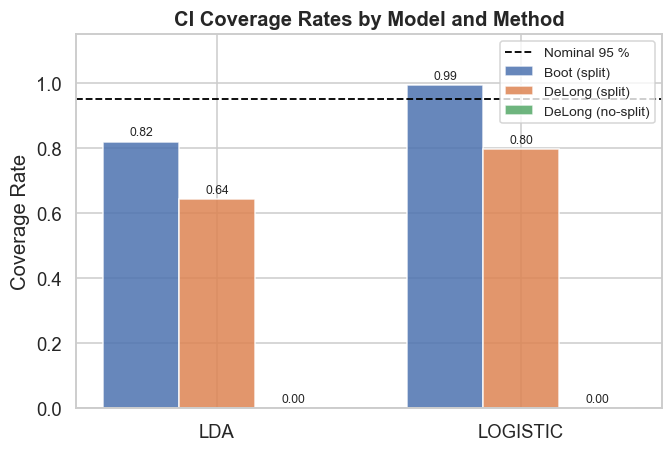


✅  All visualizations complete.


In [12]:
# ── 8d. Coverage comparison bar chart ─────────────────────────────────────────
fig_cov = plot_coverage_comparison(inference, ground_truth=gt)
plt.show()

print("\n✅  All visualizations complete.")